# 📰 NewsGenie – AI-Powered News & Information Assistant

An end-to-end implementation using:

| Component | Technology |
|---|---|
| Workflow orchestration | **LangGraph** `create_react_agent` |
| Language model | **OpenAI GPT-3.5-turbo** via LangChain (tool-calling) |
| Real-time news | **NewsAPI** |
| Web search (fallback) | **DuckDuckGo** (no API key needed) |
| Interactive UI | **Streamlit** |

## Architecture

```
User Query
    │
    ▼
OpenAI ReAct Agent  ← GPT-3.5-turbo decides which tool(s) to call
    │
 ┌──┴──────────────┐
 ▼                 ▼
get_news_tool   web_search_tool
(NewsAPI)       (DuckDuckGo)
 │                 │
 └────────┬────────┘
          ▼
   Agent processes tool results
          │
          ▼
    Final Response
```

> The agent autonomously decides whether to fetch news, search the web,
> or combine both — no hard-coded routing needed.


In [4]:
pip install requests==2.32.5

In [5]:
%pip install -q --upgrade langchain langchain-openai langchain-community langgraph \
             streamlit newsapi-python duckduckgo-search python-dotenv

## Step 1 — Configure API Keys

- **NewsAPI key** – free account at <https://newsapi.org/register>  
- **OpenAI key** – <https://platform.openai.com/api-keys>

Enter them in the cell below (input is hidden via `getpass`).

In [6]:
import os
from getpass import getpass

# ── Google Colab: load from Secrets manager ───────────────────────────
try:
    from google.colab import userdata
    _news_key   = userdata.get('NEWS_API_KEY')
    _openai_key = userdata.get('OPENAI_API_KEY')
    if _news_key:   os.environ['NEWS_API_KEY']   = _news_key
    if _openai_key: os.environ['OPENAI_API_KEY'] = _openai_key
except ImportError:
    pass  # Not running in Colab — fall through to .env / getpass below

# ── Local: load from .env file if present ────────────────────────────
try:
    from dotenv import load_dotenv
    load_dotenv(override=False)
except ImportError:
    pass

# ── Fallback: prompt interactively if still not set ──────────────────
if not os.getenv('NEWS_API_KEY', '').strip():
    _k = getpass('Enter your NewsAPI key (or press Enter to skip): ').strip()
    if _k:
        os.environ['NEWS_API_KEY'] = _k

if not os.getenv('OPENAI_API_KEY', '').strip():
    _k = getpass('Enter your OpenAI API key (or press Enter to skip): ').strip()
    if _k:
        os.environ['OPENAI_API_KEY'] = _k

news_ok   = bool(os.getenv('NEWS_API_KEY',   '').strip())
openai_ok = bool(os.getenv('OPENAI_API_KEY', '').strip())
print(f"NewsAPI key  : {'✅ set' if news_ok   else '❌ NOT SET'}")
print(f"OpenAI key   : {'✅ set' if openai_ok else '❌ NOT SET'}")


NewsAPI key  : ✅ set
OpenAI key   : ✅ set


## Step 2 — Tool Definitions

Two **LangChain tools** (decorated with `@tool`) power the agent:

1. **`get_news_tool()`** – fetches live headlines from NewsAPI (by category or keyword)
2. **`web_search_tool()`** – searches the web via DuckDuckGo (zero-config fallback)

The `@tool` decorator automatically generates the JSON schema the OpenAI function-calling API uses to decide which tool to invoke and with what arguments.


In [7]:
from typing import Optional
from newsapi import NewsApiClient
from duckduckgo_search import DDGS
from langchain_core.tools import tool

NEWS_CATEGORIES = [
    'general', 'technology', 'business', 'sports',
    'health', 'science', 'entertainment',
]

# ── NewsAPI ──────────────────────────────────────────────────────────
@tool
def get_news_tool(
    category: str = 'general',
    query: Optional[str] = None,
    page_size: int = 5,
) -> str:
    """Fetch the latest news headlines from NewsAPI.

    Use this tool when the user asks about current events, breaking news,
    top headlines, live scores, stock prices, or anything time-sensitive.

    Args:
        category: One of general, technology, business, sports, health,
                  science, or entertainment.
        query: Optional keyword(s) to filter articles (e.g. 'Apple earnings').
        page_size: Number of articles to retrieve (default 5, max 10).
    """
    api_key = os.getenv('NEWS_API_KEY', '').strip()
    if not api_key:
        return 'NEWS_API_KEY is not configured. Cannot fetch news.'
    client = NewsApiClient(api_key=api_key)
    try:
        if query:
            resp = client.get_everything(
                q=query, language='en', sort_by='relevancy', page_size=page_size)
        else:
            resp = client.get_top_headlines(
                category=category, language='en', page_size=page_size)
        articles = [
            a for a in resp.get('articles', [])
            if a.get('title') and '[Removed]' not in a.get('title', '')
        ]
        if not articles:
            return 'No articles found for the given category/query.'
        lines = []
        for i, a in enumerate(articles, 1):
            lines.append(
                f"{i}. **{a.get('title', 'No title')}** — {a.get('source', {}).get('name', 'Unknown')}\n"
                f"   {a.get('description') or 'No description.'}\n"
                f"   URL: {a.get('url', '')}\n"
                f"   Published: {a.get('publishedAt', '')}"
            )
        return '\n\n'.join(lines)
    except Exception as exc:
        return f'NewsAPI request failed: {exc}'


# ── DuckDuckGo web search ────────────────────────────────────────────
@tool
def web_search_tool(query: str, max_results: int = 5) -> str:
    """Search the web via DuckDuckGo and return relevant results.

    Use this tool for factual questions, definitions, historical information,
    how-to guides, or any query that does NOT need live news headlines.

    Args:
        query: The search query to look up.
        max_results: Maximum number of results to return (default 5).
    """
    if not query.strip():
        return 'No query provided.'
    try:
        with DDGS() as ddgs:
            hits = list(ddgs.text(query, max_results=max_results))
        if not hits:
            return 'No relevant results found.'
        lines = []
        for i, r in enumerate(hits, 1):
            lines.append(
                f"{i}. **{r.get('title', 'No title')}**\n"
                f"   {r.get('body', '')}\n"
                f"   Source: {r.get('href', '')}")
        return '\n\n'.join(lines)
    except Exception as exc:
        return f'Web search failed: {exc}'


print('Tools defined: get_news_tool, web_search_tool')
print(f'  get_news_tool schema: {get_news_tool.name}')
print(f'  web_search_tool schema: {web_search_tool.name}')


Tools defined: get_news_tool, web_search_tool
  get_news_tool schema: get_news_tool
  web_search_tool schema: web_search_tool


## Step 3 — OpenAI Agent with LangGraph

Instead of a hard-coded pipeline, we use LangGraph's `create_react_agent` to build a **proper OpenAI tool-calling agent**:

| What changes | Old approach | New approach |
|---|---|---|
| Query routing | Hard-coded `classify_query` LLM node | Agent autonomously decides which tool(s) to call |
| Workflow | Fixed 4-node graph | ReAct loop: LLM → tool → LLM → … → answer |
| Tool binding | Manual function calls | OpenAI function-calling (JSON schema auto-generated from `@tool`) |

The `create_react_agent` from `langgraph.prebuilt`:
1. Binds the tools to the LLM via OpenAI function-calling  
2. Runs a **ReAct loop** — the model calls tools as needed and reasons over results  
3. Stops when the model produces a final answer (no more tool calls)


In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import create_react_agent

# ── System prompt ────────────────────────────────────────────────────
_SYSTEM_PROMPT = (
    "You are NewsGenie, an AI-powered news and information assistant.\n\n"
    "You have two tools available:\n"
    "  • get_news_tool   — fetches live headlines from NewsAPI. Use for news, "
    "headlines, current events, live scores, market updates.\n"
    "  • web_search_tool — searches the web via DuckDuckGo. Use for factual "
    "questions, definitions, historical info, how-to guides.\n\n"
    "Guidelines:\n"
    "- Always call a tool before answering — never guess news content.\n"
    "- For news queries, pass the appropriate category and/or keyword.\n"
    "- Cite sources (article titles, URLs) in your final answer.\n"
    "- Be concise and well-structured."
)

# ── LLM ──────────────────────────────────────────────────────────────
def _get_llm(temperature: float = 0.3) -> ChatOpenAI:
    return ChatOpenAI(
        model='gpt-3.5-turbo',
        temperature=temperature,
        api_key=os.getenv('OPENAI_API_KEY', ''),
    )

# ── Build the ReAct agent graph ───────────────────────────────────────
agent_graph = create_react_agent(
    model=_get_llm(),
    tools=[get_news_tool, web_search_tool],
    prompt=_SYSTEM_PROMPT,
)

print('OpenAI ReAct agent compiled successfully via LangGraph')
print(f'  Model  : gpt-3.5-turbo')
print(f'  Tools  : {[t.name for t in [get_news_tool, web_search_tool]]}')


OpenAI ReAct agent compiled successfully via LangGraph
  Model  : gpt-3.5-turbo
  Tools  : ['get_news_tool', 'web_search_tool']


/tmp/ipykernel_6114/2762126108.py:29: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_graph = create_react_agent(


## Step 4 — Visualise the Workflow

Renders the state-machine graph as a Mermaid diagram inline.

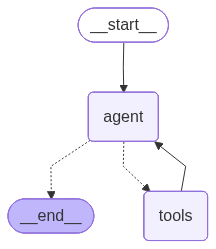

In [9]:
from IPython.display import display, Image

try:
    display(Image(agent_graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid source
    print(agent_graph.get_graph().draw_mermaid())


## Step 5 — Test the Agent

Run the ReAct agent against sample queries. The agent autonomously decides which tools to call — no routing logic needed.


In [10]:
def run_newsgenie(query: str, category: str = 'general') -> dict:
    """Invoke the NewsGenie ReAct agent.

    Includes the selected news category as a hint in the human message so
    the agent passes it to get_news_tool when fetching headlines.
    """
    # Embed category context into the query so the agent knows which category to use
    augmented_query = f"[Preferred news category: {category}] {query}"

    result = agent_graph.invoke({
        'messages': [HumanMessage(content=augmented_query)]
    })

    # The last message in the list is always the final AI answer
    final_response = result['messages'][-1].content

    # Surface which tools were called (for transparency)
    tools_called = [
        msg.name
        for msg in result['messages']
        if hasattr(msg, 'name') and msg.name
    ]

    return {
        'query':        query,
        'category':     category,
        'response':     final_response,
        'tools_called': tools_called,
        'messages':     result['messages'],
    }


test_cases = [
    ('What is machine learning?',                 'general'),
    ("Show me today's top technology headlines",  'technology'),
    ('Latest sports news',                        'sports'),
]

for query, category in test_cases:
    print('=' * 70)
    print(f'Query    : {query}')
    print(f'Category : {category}')
    result = run_newsgenie(query, category)
    print(f'Tools    : {result["tools_called"]}')
    print()
    print(result['response'])
    print()


Query    : What is machine learning?
Category : general


/tmp/ipykernel_6114/2755805107.py:74: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e030add6350>
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet

Tools    : ['web_search_tool']

Machine learning is a field of artificial intelligence that focuses on the development of algorithms and models that enable computers to learn and make decisions without being explicitly programmed. It involves the use of data and statistical techniques to allow machines to improve their performance on a task over time. 

For more information on machine learning, you can visit the following link: [Stack Overflow - What is the meaning of the word logits in TensorFlow](https://stackoverflow.com/questions/41455101/what-is-the-meaning-of-the-word-logits-in-tensorflow)

Query    : Show me today's top technology headlines
Category : technology


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Tools    : ['get_news_tool']

Here are today's top technology headlines:

1. "YouTube Premium is getting a US price hike of up to $4/month" - 9to5Google
   [Read more](http://9to5google.com/2026/04/10/youtube-premium-us-price-hike/)

2. "Marathon reportedly had a budget of $200m" - Eurogamer
   [Read more](https://www.eurogamer.net/marathon-budget-over-200-million-dollars-likely-250-million)

3. "Microsoft starts removing Copilot buttons from Windows 11 apps" - The Verge
   [Read more](https://www.theverge.com/news/909640/microsoft-removing-copilot-windows-11-buttons)

4. "Crimson Desert Dev Pearl Abyss Outlines Upcoming Changes in Response to Feedback" - IGN
   [Read more](https://www.ign.com/articles/crimson-desert-dev-confirms-boss-rematches-hard-difficulty-enemy-territory-recapture-and-a-whole-lot-more-is-coming-soon)

5. "Google Offers Free PC Upgrade For 500 Million Windows Users" - Forbes
   [Read more](https://www.forbes.com/sites/zakdoffman/2026/04/10/google-offers-free-pc-upg

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Tools    : ['get_news_tool']

Here are some of the latest sports news headlines:

1. "The best (and worst) free agent signings in MLB history" - ESPN
   [Read more](https://www.espn.com/mlb/story/_/id/48370280/mlb-2026-free-agency-ranking-best-worst-free-agent-signings-ever-50th-anniversary)

2. "Robert MacIntyre risks disciplinary action after angry Masters gesture" - ESPN
   [Read more](https://www.espn.com/golf/story/_/id/48445882/robert-macintyre-risks-disciplinary-action-angry-masters-2026-gesture)

3. "Everything that happened in Round 1 at Augusta National: Rory McIlroy, Sam Burns lead stars who ace'd the test" - CBS Sports
   [Read more](https://www.cbssports.com/golf/news/masters-2026-live-updates-round-1-leaderboard-scores-results/live/)

4. "Liam Coen says he and the Jaguars’ staff are 'a little less frantic' heading into Year 2" - NBC Sports
   [Read more](https://www.nbcsports.com/nfl/profootballtalk/rumor-mill/news/liam-coen-says-he-and-the-jaguars-staff-are-a-little-less

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 6 — Interactive Query

Run a single custom query. Edit `my_query` and `my_category` and re-run the cell.


In [11]:
# Edit query and category, then run this cell
my_query    = 'Latest AI research news'
my_category = 'technology'

result = run_newsgenie(my_query, my_category)
print(f"Tools called : {result['tools_called']}")
print()
print(result['response'])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Tools called : ['get_news_tool']

One of the latest AI research news is about Anthropic launching a new think tank amid a conflict with the Pentagon. The company is introducing the Anthropic Institute as part of its research initiatives. [Read more](https://www.theverge.com/ai-artificial-intelligence/892478/anthropic-institute-think-tank-claude-pentagon-jack-clark)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 7 — Launch Streamlit UI

The next two cells write a self-contained `app.py` (using the same OpenAI ReAct agent pattern) then start the server.  
Open **http://localhost:8501** in your browser.


In [12]:
app_code = '''
import os
from typing import Optional

import streamlit as st
from dotenv import load_dotenv
from newsapi import NewsApiClient
from duckduckgo_search import DDGS
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

load_dotenv()

NEWS_CATEGORIES = ['general', 'technology', 'business', 'sports',
                   'health', 'science', 'entertainment']

_SYSTEM_PROMPT = (
    "You are NewsGenie, an AI-powered news and information assistant.\\n\\n"
    "You have two tools:\\n"
    "  • get_news_tool   — fetches live headlines from NewsAPI. Use for news, "
    "headlines, current events, live scores, market updates.\\n"
    "  • web_search_tool — searches the web via DuckDuckGo. Use for factual "
    "questions, definitions, historical info, how-to guides.\\n\\n"
    "Always call a tool before answering. Cite sources in your final reply."
)


@tool
def get_news_tool(category: str = "general",
                  query: Optional[str] = None,
                  page_size: int = 5) -> str:
    """Fetch the latest news headlines from NewsAPI.

    Use for news, headlines, current events, live scores, market updates.

    Args:
        category: One of general, technology, business, sports, health,
                  science, or entertainment.
        query: Optional keyword filter (e.g. "Apple earnings").
        page_size: Number of articles (default 5).
    """
    api_key = os.getenv("NEWS_API_KEY", "").strip()
    if not api_key:
        return "NEWS_API_KEY is not configured."
    client = NewsApiClient(api_key=api_key)
    try:
        if query:
            resp = client.get_everything(
                q=query, language="en", sort_by="relevancy", page_size=page_size)
        else:
            resp = client.get_top_headlines(
                category=category, language="en", page_size=page_size)
        articles = [
            a for a in resp.get("articles", [])
            if a.get("title") and "[Removed]" not in a.get("title", "")
        ]
        if not articles:
            return "No articles found."
        lines = []
        for i, a in enumerate(articles, 1):
            lines.append(
                f"{i}. **{a.get('title', '')}** — {a.get('source', {}).get('name', 'Unknown')}\\n"
                f"   {a.get('description') or ''}\\n"
                f"   URL: {a.get('url', '')}\\n"
                f"   Published: {a.get('publishedAt', '')}"
            )
        return "\\n\\n".join(lines)
    except Exception as exc:
        return f"NewsAPI error: {exc}"


@tool
def web_search_tool(query: str, max_results: int = 5) -> str:
    """Search the web via DuckDuckGo.

    Use for factual questions, definitions, history, how-to guides.

    Args:
        query: The search query.
        max_results: Maximum results to return (default 5).
    """
    if not query.strip():
        return "No query provided."
    try:
        with DDGS() as d:
            hits = list(d.text(query, max_results=max_results))
        if not hits:
            return "No results found."
        return "\\n\\n".join(
            f"{i}. **{r.get('title', '')}**\\n   {r.get('body', '')}\\n   {r.get('href', '')}"
            for i, r in enumerate(hits, 1)
        )
    except Exception as e:
        return f"Search failed: {e}"


@st.cache_resource
def get_agent():
    llm = ChatOpenAI(
        model="gpt-3.5-turbo",
        temperature=0.3,
        api_key=os.getenv("OPENAI_API_KEY", ""),
    )
    return create_react_agent(
        model=llm,
        tools=[get_news_tool, web_search_tool],
        prompt=_SYSTEM_PROMPT,
    )


# ── UI ────────────────────────────────────────────────────────────────
st.set_page_config(page_title="NewsGenie", page_icon="📰", layout="wide",
                   initial_sidebar_state="expanded")

st.markdown("""<style>
.news-card{background:#f8f9fa;border-left:4px solid #1a73e8;border-radius:6px;
           padding:12px 16px;margin-bottom:10px;}
.news-card h4{margin:0 0 4px 0;color:#1a1a1a;}
.news-card p{margin:0;color:#555;font-size:.9rem;}
.news-card a{color:#1a73e8;font-size:.85rem;}
.badge{display:inline-block;background:#e8f0fe;color:#1a73e8;border-radius:12px;
       padding:2px 10px;font-size:.8rem;font-weight:600;margin-right:6px;}
.user-bubble{background:#1a73e8;color:white;border-radius:16px 16px 4px 16px;
             padding:10px 16px;margin:6px 0 6px auto;max-width:80%;width:fit-content;}
.bot-bubble{background:#f1f3f4;color:#202124;border-radius:16px 16px 16px 4px;
            padding:10px 16px;margin:6px auto 6px 0;max-width:80%;}
#MainMenu{visibility:hidden;}footer{visibility:hidden;}
</style>""", unsafe_allow_html=True)

if "messages" not in st.session_state:
    st.session_state.messages = []
if "category" not in st.session_state:
    st.session_state.category = "general"

with st.sidebar:
    st.title("📰 NewsGenie")
    st.caption("AI-powered news & information assistant")
    st.divider()
    st.subheader("🗂 News Category")
    st.session_state.category = st.selectbox(
        "Category:", options=NEWS_CATEGORIES,
        index=NEWS_CATEGORIES.index(st.session_state.category),
        format_func=str.title,
    )
    st.divider()
    st.subheader("🔑 API Status")
    nok = bool(os.getenv("NEWS_API_KEY", "").strip())
    aok = bool(os.getenv("OPENAI_API_KEY", "").strip())
    st.markdown(f"{'✅' if nok else '❌'} NewsAPI  \\n{'✅' if aok else '❌'} OpenAI")
    if not (nok and aok):
        st.warning("Set NEWS_API_KEY and OPENAI_API_KEY in your .env file.")
    st.divider()
    st.subheader("💡 Examples")
    for ex in ["Latest tech headlines", "Top sports news today",
               "What is quantum computing?", "Latest business news",
               "Who invented the internet?"]:
        if st.button(ex, use_container_width=True, key=f"ex_{ex}"):
            st.session_state._pending = ex
    st.divider()
    if st.button("🗑 Clear Chat", use_container_width=True):
        st.session_state.messages = []
        st.rerun()

st.markdown("## 📰 NewsGenie — AI-Powered News & Information Assistant")
st.caption("Ask about headlines or any general question. The agent decides which tools to use.")
st.divider()

for msg in st.session_state.messages:
    if msg["role"] == "user":
        st.markdown(
            f\'<div class="user-bubble">🧑 {msg["content"]}</div>\',
            unsafe_allow_html=True)
    else:
        st.markdown(
            \'<div class="bot-bubble">🤖 <strong>NewsGenie</strong></div>\',
            unsafe_allow_html=True)
        st.markdown(msg["content"])

if not st.session_state.messages:
    st.info("👋 Welcome! Type a query below or pick an example from the sidebar.")

pending = st.session_state.pop("_pending", None)
with st.form(key="chat_form", clear_on_submit=True):
    c1, c2 = st.columns([6, 1])
    with c1:
        user_input = st.text_input(
            "Query", value=pending or "",
            placeholder="e.g. \\'Latest AI news\\' or \\'What is LangGraph?\\'",
            label_visibility="collapsed",
        )
    with c2:
        submitted = st.form_submit_button("Send ➤", use_container_width=True)

if submitted and user_input.strip():
    q = user_input.strip()
    st.session_state.messages.append({"role": "user", "content": q})
    with st.spinner("Thinking…"):
        try:
            if not os.getenv("OPENAI_API_KEY", "").strip():
                raise EnvironmentError("OPENAI_API_KEY is not set.")
            augmented = f"[Preferred news category: {st.session_state.category}] {q}"
            result = get_agent().invoke({
                "messages": [HumanMessage(content=augmented)]
            })
            resp_text = result["messages"][-1].content
        except Exception as exc:
            resp_text = f"⚠️ Error: {exc}"
    st.session_state.messages.append({"role": "assistant", "content": resp_text})
    st.rerun()
'''

with open('app.py', 'w', encoding='utf-8') as fh:
    fh.write(app_code)

print('app.py written (OpenAI ReAct agent version).')
print('Run:  streamlit run app.py')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

app.py written (OpenAI ReAct agent version).
Run:  streamlit run app.py


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(f'Streamlit server started (PID {proc.pid}).')
print('Open http://localhost:8501 in your browser.')
print('To stop: proc.terminate()')

Streamlit server started (PID 7338).
Open http://localhost:8501 in your browser.
To stop: proc.terminate()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Accessing Streamlit UI with `ngrok`

Since the direct `localhost` link might not be accessible from your browser, we'll use `ngrok` to create a public URL for the Streamlit application.

1.  **Install `pyngrok`**

In [14]:
pip install pyngrok

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

2.  **Get your `ngrok` Auth Token**

    *   Go to [ngrok.com](https://ngrok.com/) and sign up for a free account.
    *   Once logged in, go to your dashboard to find your authtoken.
    *   Add this token to Colab's Secrets manager (the '🔑' icon on the left panel) with the name `NGROK_AUTH_TOKEN`.

3.  **Connect `ngrok` to Streamlit**

    The Streamlit app is running on port `8501`. We'll use `ngrok` to tunnel this port and get a public URL.

In [16]:
from google.colab import userdata
from pyngrok import ngrok, conf

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("ngrok authtoken set.")
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

# Open a ngrok tunnel to the Streamlit port (8501)
tunnel = ngrok.connect(8501)
print(f"Streamlit App URL: {tunnel.public_url}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
ngrok.kill()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Now, use the `Streamlit App URL` provided above to access your application in your web browser. If you want to stop the Streamlit server and the `ngrok` tunnel, remember to run `proc.terminate()` and `ngrok.kill()` respectively.

### Alternative: Accessing Streamlit UI with `localtunnel`

If you prefer an alternative to `ngrok`, `localtunnel` is another popular choice to create a public URL for your local server. It typically does not require an authentication token.

In [ ]:
# First, install Node.js and npm (usually already available in Colab)
# Then, install localtunnel globally using npm
!npm install -g localtunnel

Now, let's start `localtunnel` on port `8501` where the Streamlit app is running.

In [ ]:
import subprocess
import threading
import time

def run_localtunnel():
    # Use the localtunnel command directly
    command = ['lt', '--port', '8501']
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    # Wait a bit for localtunnel to start and print its URL
    time.sleep(5)

    stdout, stderr = process.communicate(timeout=15)
    print(stdout)
    if stderr:
        print(f"Error from localtunnel: {stderr}")

# Run localtunnel in a separate thread to avoid blocking the notebook
localtunnel_thread = threading.Thread(target=run_localtunnel)
localtunnel_thread.start()
print("Localtunnel is starting. Please wait for the public URL to appear.")
print("You might need to manually check the output or re-run this cell after a few seconds if the URL doesn't appear immediately.")


You should see the public `localtunnel` URL in the output above. Copy that URL and paste it into your browser to access the Streamlit application. To stop the `localtunnel` process, you may need to interrupt the kernel or restart the runtime.

---

## Step 8 — Export Notebook as PDF

Converts this notebook to a PDF using `nbconvert`'s **WebPDF** renderer (powered by a headless Chromium browser — no LaTeX required).

Steps:
1. Install `nbconvert` with the web PDF extras
2. Run the conversion (produces `Agentic_Way_NewsGenie.pdf` in the same folder)
3. Download the PDF automatically via Colab's file download helper


In [ ]:
# Install nbconvert with the webpdf extra (includes Chromium support)
%pip install -q "nbconvert[webpdf]"


In [ ]:
import subprocess, pathlib

NOTEBOOK = 'Agentic_Way_NewsGenie.ipynb'
OUTPUT_PDF = pathlib.Path(NOTEBOOK).stem + '.pdf'

result = subprocess.run(
    [
        'jupyter', 'nbconvert',
        '--to', 'webpdf',
        '--allow-chromium-download',
        '--no-input',          # hide code cells for a cleaner output report
        '--output', OUTPUT_PDF,
        NOTEBOOK,
    ],
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print(f'✅ PDF created: {OUTPUT_PDF}')
else:
    print('❌ Conversion failed.')
    print(result.stdout)
    print(result.stderr)


In [ ]:
# Download the PDF (Google Colab only)
try:
    from google.colab import files
    files.download(OUTPUT_PDF)
    print(f'📥 Download started for {OUTPUT_PDF}')
except ImportError:
    print(f'ℹ️  Not running in Colab. Find your PDF at: {pathlib.Path(OUTPUT_PDF).resolve()}')
